### Accessing JSON data through an API
#### Yelp Fusion API
1. Obtain a Yelp Fusion Developer Account here: https://fusion.yelp.com/ Use your student email and access your email to verify your account.
2. Create a Yelp Fusion App.  Login to your Yelp developer account, and select Manage App under General.  Enter an App Name (such as Review Sentiments), your email and a description. 
3. Save your client id and api key in a separate (private) .py file.  This script assumes that this information is saved in yelpkeys.py with the variables client_id and api_key respectively.
4. Import your id and key into your notebook by importing the file containing this private information.


# Sentiment Analysis of NJ Coffee Shops 
##### **Name**: Gina Socolich
##### **Date**: 1 May 2025

## Description
I want to explore customer sentiment towards coffee shops in New Jersey through analyzing Yelp reviews. Are most reviews positive, negative, or neutral? What are some of the top rated shops? What are some common themes between reviews?

I will:
- Gather at least 60 reviews from various businesses
- Analyze sentiment using two different analyzers
- Visualize sentiment and word trends

In [33]:
import requests
import yelpkeys  # file where client_id and api_key is defined with user's private app information
from textblob import TextBlob

In [34]:
APIKEY = yelpkeys.api_key
headers = {'Authorization': 'Bearer %s' % yelpkeys.api_key,}

In [35]:
"""
Yelp Fusion API code sample.
This program demonstrates the capability of the Yelp Fusion API
by using the Search API to query for businesses by a search term and location,
and the Business API to query additional information about the top result
from the search query.
Please refer to https://docs.developer.yelp.com/docs/get-started for the API
documentation.
This program requires the Python requests library, which you can install via:
`pip install -r requirements.txt`.
Sample usage of the program:
`python sample.py --term="bars" --location="San Francisco, CA"`
"""
from __future__ import print_function

import argparse
import json
import pprint
import requests
import sys
import urllib


# This client code can run on Python 2.x or 3.x.  Your imports can be
# simpler if you only need one of those.
try:
    # For Python 3.0 and later
    from urllib.error import HTTPError
    from urllib.parse import quote
    from urllib.parse import urlencode
except ImportError:
    # Fall back to Python 2's urllib2 and urllib
    from urllib2 import HTTPError
    from urllib import quote
    from urllib import urlencode


# Yelp Fusion no longer uses OAuth as of December 7, 2017.
# You no longer need to provide Client ID to fetch Data
# It now uses private keys to authenticate requests (API Key)
# You can find it on
# https://www.yelp.com/developers/v3/manage_app
API_KEY= yelpkeys.api_key


# API constants, you shouldn't have to change these.
API_HOST = 'https://api.yelp.com'
SEARCH_PATH = '/v3/businesses/search'
BUSINESS_PATH = '/v3/businesses/'  # Business ID will come after slash.


DEFAULT_TERM = 'coffee'
DEFAULT_LOCATION = 'Jersey City, NJ'
SEARCH_LIMIT = 20


def request(host, path, api_key, url_params=None):
    """Given your API_KEY, send a GET request to the API.
    Args:
        host (str): The domain host of the API.
        path (str): The path of the API after the domain.
        API_KEY (str): Your API Key.
        url_params (dict): An optional set of query parameters in the request.
    Returns:
        dict: The JSON response from the request.
    Raises:
        HTTPError: An error occurs from the HTTP request.
    """
    url_params = url_params or {}
    url = '{0}{1}'.format(host, quote(path.encode('utf8')))
    headers = {
        'Authorization': 'Bearer %s' % api_key,
    }

    print(u'Querying {0} ...'.format(url))

    response = requests.request('GET', url, headers=headers, params=url_params)

    return response.json()


def search(api_key, term, location):
    """Query the Search API by a search term and location.
    Args:
        term (str): The search term passed to the API.
        location (str): The search location passed to the API.
    Returns:
        dict: The JSON response from the request.
    """

    url_params = {
        'term': term.replace(' ', '+'),
        'location': location.replace(' ', '+'),
        'limit': SEARCH_LIMIT
    }
    return request(API_HOST, SEARCH_PATH, api_key, url_params=url_params)


def get_business(api_key, business_id):
    """Query the Business API by a business ID.
    Args:
        business_id (str): The ID of the business to query.
    Returns:
        dict: The JSON response from the request.
    """
    business_path = BUSINESS_PATH + business_id

    return request(API_HOST, business_path, api_key)


def query_api(term, location):
    """Queries the API by the input values from the user.
    Args:
        term (str): The search term to query.
        location (str): The location of the business to query.
    """
    response = search(API_KEY, term, location)

    businesses = response.get('businesses')

    if not businesses:
        print(u'No businesses for {0} in {1} found.'.format(term, location))
        return

    business_id = businesses[0]['id']

    print(u'{0} businesses found, querying business info ' \
        'for the top result "{1}" ...'.format(
            len(businesses), business_id))
    response = get_business(API_KEY, business_id)

    print(u'Result for business "{0}" found:'.format(business_id))
    pprint.pprint(response, indent=2)

In [36]:
response = search(API_KEY,DEFAULT_TERM, 'Randolph, NJ')

Querying https://api.yelp.com/v3/businesses/search ...


In [37]:
response

{'businesses': [{'id': '-7zxF98ZRLqvOCvHIDMeKQ',
   'alias': 'anechó-coffee-randolph',
   'name': 'Anechó Coffee',
   'image_url': 'https://s3-media4.fl.yelpcdn.com/bphoto/qkrsmiWfQxZMF6yE5YBrUQ/o.jpg',
   'is_closed': False,
   'url': 'https://www.yelp.com/biz/anech%C3%B3-coffee-randolph?adjust_creative=istl9jgw2i0Hp64EIdomvQ&utm_campaign=yelp_api_v3&utm_medium=api_v3_business_search&utm_source=istl9jgw2i0Hp64EIdomvQ',
   'review_count': 1,
   'categories': [{'alias': 'coffee', 'title': 'Coffee & Tea'},
    {'alias': 'streetvendors', 'title': 'Street Vendors'}],
   'rating': 5.0,
   'coordinates': {'latitude': 40.8520882, 'longitude': -74.5814465},
   'transactions': [],
   'location': {'address1': None,
    'address2': None,
    'address3': '',
    'city': 'Randolph',
    'zip_code': '07869',
    'country': 'US',
    'state': 'NJ',
    'display_address': ['Randolph, NJ 07869']},
   'phone': '+18628128785',
   'display_phone': '(862) 812-8785',
   'distance': 13.128714524446915},
  {'

In [38]:
for business in response['businesses']:
    #print(response)
    print('Business Name: ' + business['name'])
    print('Rating: ' + str(business['rating']))
    print('Review Count: ' + str(business['review_count']))
    print('Reviews: ')
    BUS_REVIEW='/v3/businesses/{}/reviews'.format(business['id'])
    #print('https://api.yelp.com/v3/businesses/{}/reviews?limit=20&sort_by=yelp_sort'.format(business['id']))
    reviews = request(API_HOST,BUS_REVIEW, API_KEY)
    for review in reviews['reviews']:
        print(' - ' + review['text'])
        # Perform sentiment analysis on the review using TextBlob
        blob = TextBlob(review['text'])
        sentiment = blob.sentiment.polarity
        if sentiment > 0:
            print('    Sentiment: Positive')
        elif sentiment < 0:
            print('    Sentiment: Negative')
        else:
            print('    Sentiment: Neutral')
        print('\n================\n\n\n')

Business Name: Anechó Coffee
Rating: 5.0
Review Count: 1
Reviews: 
Querying https://api.yelp.com/v3/businesses/-7zxF98ZRLqvOCvHIDMeKQ/reviews ...
 - Nikki and her team at Anechó Coffee are absolutely perfect. We planned a Pop-Up, but due to increased demand at the last minute, we could no longer brew...
    Sentiment: Positive




Business Name: The Good Bean
Rating: 4.7
Review Count: 38
Reviews: 
Querying https://api.yelp.com/v3/businesses/Ng7EEXGmqwgo-v-1ArNmNw/reviews ...
 - Amazing place but only one bad thing. One worker that usually works in the afternoon has the worst attitude on the job. Rushes all the products he makes and...
    Sentiment: Negative




 - I tried this place for the first time today and it was great. Cozy spot, organized, and good service. I got the cinnamon French toast latte and it was...
    Sentiment: Positive




 - First time there Saturday, and the cinnamon French toast latte was a hit! It's one of their most popular items. Very sweet, but also a good b

### Simple code for creating a donut chart (courtesy of chatGPT)

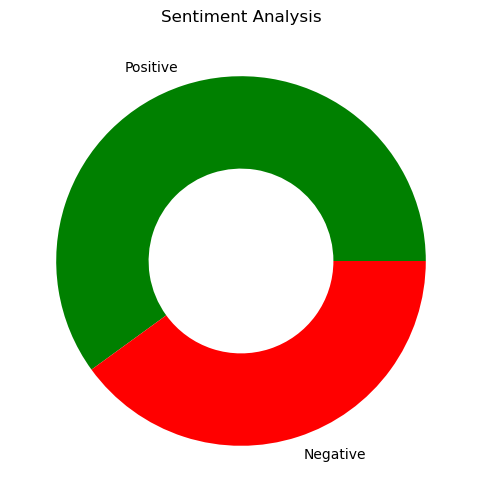

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define data
pos = 60
neg = 40
labels = ['Positive', 'Negative']
values = [pos, neg]

# Create donut chart
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(values, labels=labels, wedgeprops=dict(width=0.5), colors=['green', 'red'])
ax.set_title('Sentiment Analysis')

plt.show()

In [40]:
import pandas as pd
import re
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stops = stopwords.words('english')

review_data = []

response = search(API_KEY, DEFAULT_TERM, 'Jersey City, NJ')

#ChatGPT: for loop
for business in response['businesses']:
    BUS_REVIEW = f'/v3/businesses/{business["id"]}/reviews'
    reviews = request(API_HOST, BUS_REVIEW, API_KEY)
    for review in reviews['reviews']:
        text = review['text']
        blob = TextBlob(text)
        sentiment = blob.sentiment.polarity
        
        cleaned = re.sub(r'[^A-Za-z\s]', '', text.lower())
        words = cleaned.split()
        words = [word for word in words if word not in stop_words]
        cleaned_review = ' '.join(words)

        review_data.append({
            'business': business['name'],
            'original_text': text,
            'cleaned_text': cleaned_review,
            'sentiment': sentiment
        })

df = pd.DataFrame(review_data)
df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ginas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Querying https://api.yelp.com/v3/businesses/search ...
Querying https://api.yelp.com/v3/businesses/m8nwhonTWgNGeDEEHXxV6w/reviews ...
Querying https://api.yelp.com/v3/businesses/XSD40vlGKk7ehR9eKgfapQ/reviews ...
Querying https://api.yelp.com/v3/businesses/Qyluj1pQN3QAwaslpJSQ3g/reviews ...
Querying https://api.yelp.com/v3/businesses/aNCF4-9nH3hbLJXqIW3EgA/reviews ...
Querying https://api.yelp.com/v3/businesses/pCkbkqKAHHU9gS-5N9cw6w/reviews ...
Querying https://api.yelp.com/v3/businesses/hL3cPiuZrQBN5goCOR3rXQ/reviews ...
Querying https://api.yelp.com/v3/businesses/9u3pVclPbKRbE2Tc-m3dEA/reviews ...
Querying https://api.yelp.com/v3/businesses/iJjW-8s8VdROnAJfbG5wkg/reviews ...
Querying https://api.yelp.com/v3/businesses/T6DcfR-o8q7QkqLniQdoCA/reviews ...
Querying https://api.yelp.com/v3/businesses/smmL8FRhgF_-HTzmSqxm_w/reviews ...
Querying https://api.yelp.com/v3/businesses/qkP1W5QhW8WkbwvqO5pVBQ/reviews ...
Querying https://api.yelp.com/v3/businesses/kbn1RqXmAVnDlyQNAtrYCA/reviews .

,business,original_text,cleaned_text,sentiment
0,Bleu Coffee,This is my favourite spot in Jersey City. It i...,favourite spot jersey city clean spacious pret...,0.205556
1,Bleu Coffee,My friend and I came here on a rainy Saturday ...,friend came rainy saturday afternoon many open...,0.178571
2,Bleu Coffee,"Lots of seating--there's outdoor, a first floo...",lots seatingtheres outdoor first floor second ...,0.130000
3,Snapdragon Coffee & Social,"Above all else, the service here is really gre...",else service really great one baristas nati so...,0.453667
4,Snapdragon Coffee & Social,Decided to stop by snapdragon while in the nei...,decided stop snapdragon neighborhood eclectic ...,0.087500


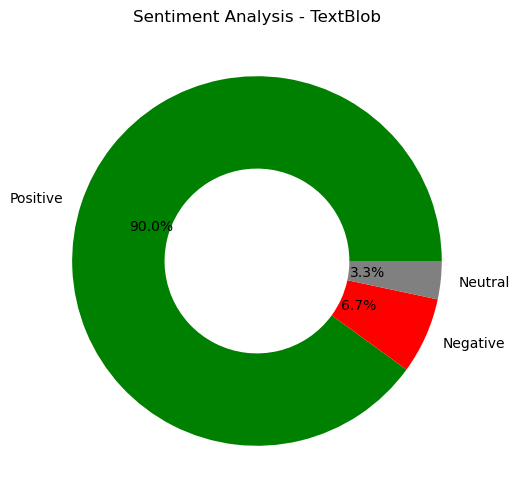

In [41]:
#ChatGPT: donut chart
df['sentiment_label'] = df['sentiment'].apply(
    lambda x: 'Positive' if x > 0 else 'Negative' if x < 0 else 'Neutral'
)

sent_counts = df['sentiment_label'].value_counts()
labels = sent_counts.index
sizes = sent_counts.values
colors = ['green', 'red', 'gray']

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, wedgeprops=dict(width=0.5), colors=colors, autopct='%1.1f%%')
ax.set_title('Sentiment Analysis - TextBlob')
plt.show()

In [ ]:
from textblob import TextBlob
from textblob.sentiments import NaiveBayesAnalyzer

sentiments = []

for text in df['original_text']:
    blob = TextBlob(text, analyzer=NaiveBayesAnalyzer())
    classification = blob.sentiment.classification
    sentiments.append(classification)

df['sentiment'] = sentiments

counts = df['sentiment'].value_counts()
labels = counts.index
sizes = counts.values
colors = ['green', 'red']  

#ChatGPT: donut chart
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, wedgeprops=dict(width=0.5), colors=colors, autopct='%1.1f%%')
ax.set_title('Sentiment Analysis - NaiveBayesAnalyzer')
plt.show()

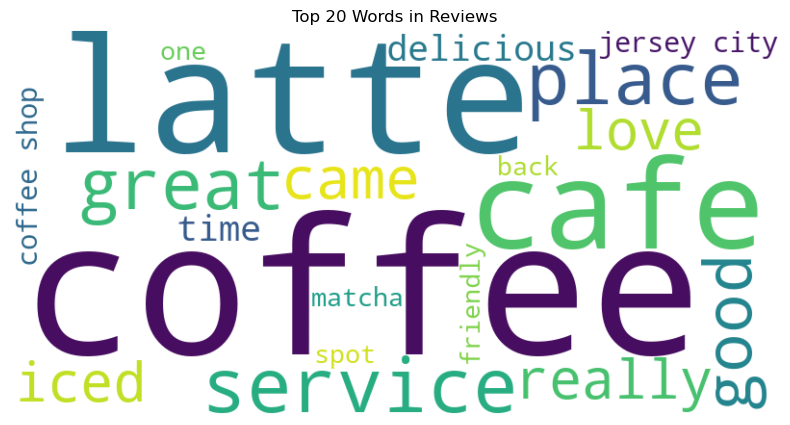

In [ ]:
from wordcloud import WordCloud

all_words = ' '.join(df['cleaned_text'])

wordcloud = WordCloud(width=800, height=400, max_words=20, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 20 Words in Reviews')
plt.show()

# Conclusion

Based on the analysis of 60+ Yelp reviews for coffee shops in Jersey City:

- The majority of reviews were positive, proving high customer satisfaction.
- The NaiveBayesAnalyzer and TextBlob aligned as far as the above notion, but had different classifications and percentages.
- Common review themes include "service", "friendly", and "delicious".

These results suggest that both the product and service quality produced mostly positive sentiments.